<a href="https://colab.research.google.com/github/joyhwp/personal_projects/blob/main/%20%2001_NLP_IMDB_Sentiment_Analysis/nlp_imdb_sentiment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **IMDB 영화 리뷰 감성 분석 (NLP Sentiment Analysis)**
---

### **과제 안내 사항**

**<분석 목적>**  
IMDB 영화 리뷰 텍스트 데이터를 활용하여, 리뷰 내용만으로 긍정/부정 감성을 예측하는 자연어 처리 모델을 구축함. 텍스트 데이터의 정제부터 특징 추출, 모델링까지의 전체 파이프라인을 설계하고, 영화 리뷰라는 비정형 텍스트에서 유의미한 패턴을 도출하는 것



## 1. 데이터 전처리 및 EDA

### (1) 데이터 로드

In [ ]:
pip install scikit-learn gensim tqdm pandas numpy matplotlib seaborn

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation,TruncatedSVD, NMF
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.feature_extraction.text import CountVectorizer
from gensim.corpora.dictionary import Dictionary
from gensim.models.ldamodel import LdaModel
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# MeCab 및 관련 패키지 설치
!curl -s https://raw.githubusercontent.com/konlpy/konlpy/master/scripts/mecab.sh | bash

# 라이브러리 설치
!pip install konlpy mecab-python3

# 재시작 후 아래 코드 실행
from konlpy.tag import Mecab

In [ ]:
import pandas as pd

df = pd.read_csv("/content/IMDB Dataset.csv")
df


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='sentiment', data=df)
plt.title('Sentiment Distribution')
plt.show()


### (2) 텍스트 전처리

In [ ]:
import nltk

# 안전하게 필요한 리소스 모두 확보
for pkg in ["punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4"]:
    try:
        # punkt와 punkt_tab는 위치가 다름
        res = ("tokenizers/punkt" if pkg=="punkt" else
               "tokenizers/punkt_tab" if pkg=="punkt_tab" else
               f"corpora/{pkg}")
        nltk.data.find(res)
    except LookupError:
        nltk.download(pkg)


In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# NLTK 리소스 다운로드 (최초 1회만 필요)
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

# WordNet Lemmatizer 생성
lemmatizer = WordNetLemmatizer()

# 영어 불용어 목록 불러오기
def load_stopwords():
    stop_words = set(stopwords.words('english'))
    # 감정 분석에서 중요한 부정어(not, no, never)는 유지
    keep_words = {'no', 'not', 'nor', 'never'}
    stop_words = stop_words - keep_words
    return stop_words

stopwords_en = load_stopwords()

# 텍스트 전처리 (전처리된 텍스트를 담을 리스트)
processed_texts = []

for text in df['review']:
    text = re.sub(r'(<br\s*/?>)+', ' ', text)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'&[a-z]+;', ' ', text)
    # 1. 특수문자 제거 (영문자와 공백만 남김)
    cleaned_text = re.sub(r"[^a-zA-Z\s]", "", str(text))

    # 2. 소문자 변환
    cleaned_text = cleaned_text.lower()

    # 3. 토큰화
    tokens = word_tokenize(cleaned_text)

    # 4. 불용어 제거 및 짧은 단어 제거
    filtered_tokens = [w for w in tokens if w not in stopwords_en and len(w) > 1]

    # 5. 표제어 추출 (Lemmatization)
    lemmatized_tokens = [lemmatizer.lemmatize(w) for w in filtered_tokens]

    # 6. 최종 텍스트 저장
    processed_texts.append(" ".join(lemmatized_tokens))


In [ ]:
# TF-IDF 벡터화 (NMF, LSA용)
tfidf_vectorizer = TfidfVectorizer(max_df=0.9, min_df=5)
tfidf_matrix = tfidf_vectorizer.fit_transform(processed_texts)

# Count 벡터화 (LDA용)
count_vectorizer = CountVectorizer(max_df=0.9, min_df=5)
count_matrix = count_vectorizer.fit_transform(processed_texts)

In [ ]:
import pandas as pd
df['clean_review'] = processed_texts


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 리뷰 길이(단어 수)
df['review_len'] = df['clean_review'].str.split().apply(len)

# 분포 히스토그램
plt.figure(figsize=(9,5))
sns.histplot(data=df, x='review_len', hue='sentiment', bins=50, kde=True, element='step', stat='density')
plt.title('Review Length Distribution by Sentiment')
plt.xlabel('Number of Tokens (cleaned)')
plt.ylabel('Density')
plt.tight_layout()
plt.show()

# 박스플롯으로 비교
plt.figure(figsize=(7,4))
sns.boxplot(data=df, x='sentiment', y='review_len')
plt.title('Review Length by Sentiment')
plt.xlabel('Sentiment'); plt.ylabel('Number of Tokens (cleaned)')
plt.tight_layout()
plt.show()

# 요약 통계
length_stats = df.groupby('sentiment')['review_len'].describe()
print(length_stats)


Top Positive Words


,word,freq
3423,film,48751
5948,movie,43925
6173,not,28981
6301,one,27535
5294,like,17664
9080,time,15639
3889,good,14642
8590,story,13912
1444,character,13827
3963,great,12860


Top Negative Words


,word,freq
5808,movie,57033
3342,film,42823
6043,not,33180
6172,one,26276
5171,like,22358
6001,no,15546
3044,even,15100
9049,time,14611
3795,good,14388
654,bad,14376


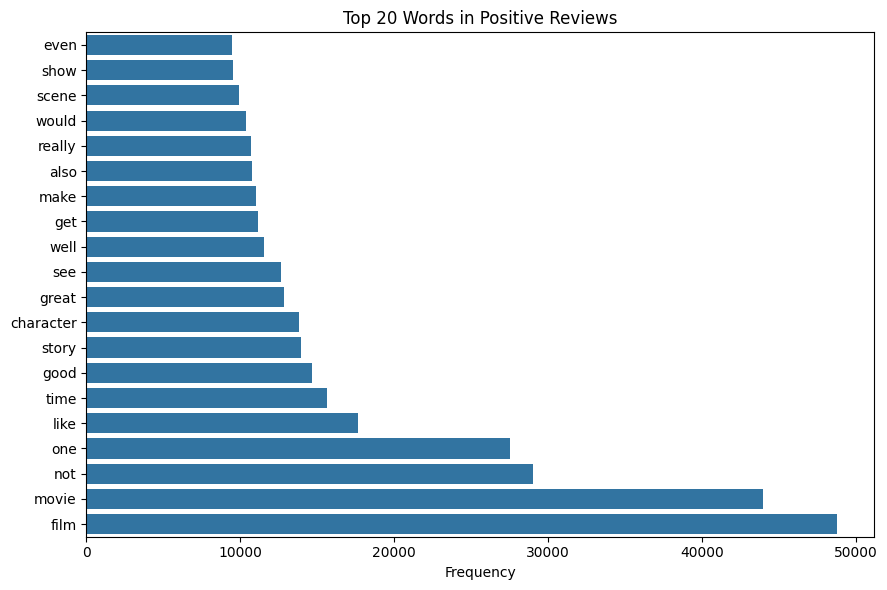

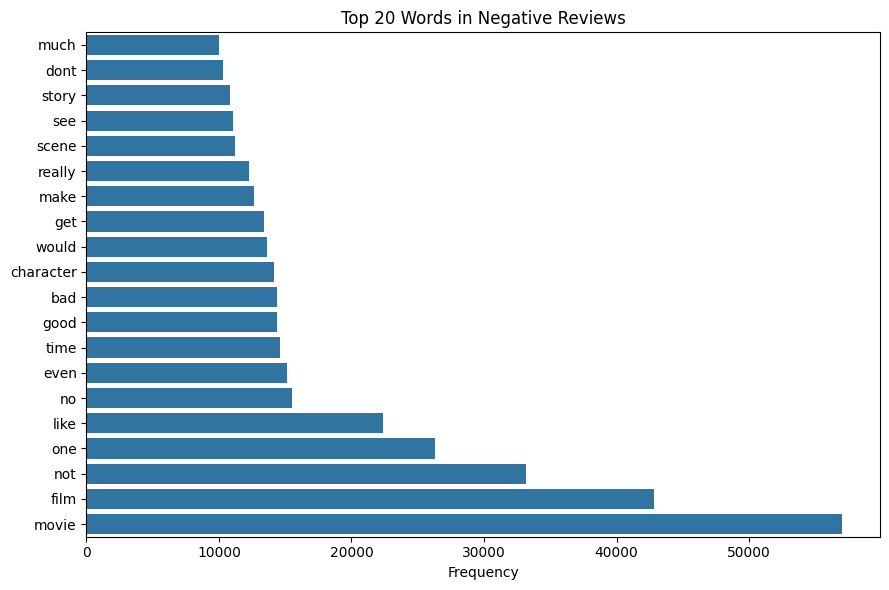

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

TOPK = 20  # 상위 N개 단어

# 감정별 코퍼스
pos_texts = df.loc[df['sentiment']=='positive', 'clean_review']
neg_texts = df.loc[df['sentiment']=='negative', 'clean_review']

# Vectorizer (이미 불용어 제거되어 있으니 stop_words=None)
cv = CountVectorizer(max_features=10000)
X_pos = cv.fit_transform(pos_texts)
pos_vocab = cv.get_feature_names_out()
pos_counts = X_pos.sum(axis=0).A1
pos_freq = pd.DataFrame({'word': pos_vocab, 'freq': pos_counts}).sort_values('freq', ascending=False).head(TOPK)

cv = CountVectorizer(max_features=10000)
X_neg = cv.fit_transform(neg_texts)
neg_vocab = cv.get_feature_names_out()
neg_counts = X_neg.sum(axis=0).A1
neg_freq = pd.DataFrame({'word': neg_vocab, 'freq': neg_counts}).sort_values('freq', ascending=False).head(TOPK)

print("Top Positive Words")
display(pos_freq)

print("Top Negative Words")
display(neg_freq)

# 막대그래프 (Positive)
plt.figure(figsize=(9,6))
sns.barplot(data=pos_freq.sort_values('freq', ascending=True), x='freq', y='word')
plt.title(f'Top {TOPK} Words in Positive Reviews')
plt.xlabel('Frequency'); plt.ylabel('')
plt.tight_layout()
plt.show()

# 막대그래프 (Negative)
plt.figure(figsize=(9,6))
sns.barplot(data=neg_freq.sort_values('freq', ascending=True), x='freq', y='word')
plt.title(f'Top {TOPK} Words in Negative Reviews')
plt.xlabel('Frequency'); plt.ylabel('')
plt.tight_layout()
plt.show()


In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 한 줄로 합치기
pos_blob = " ".join(pos_texts.tolist())
neg_blob = " ".join(neg_texts.tolist())

# 제외할 단어 지정
custom_stopwords = {'film', 'movie', 'movies', 'films'}

# Positive WordCloud
wc_pos = WordCloud(
    width=1000, height=500,
    background_color='white',
    stopwords=custom_stopwords,
    collocations=False
).generate(pos_blob)

# Negative WordCloud
wc_neg = WordCloud(
    width=1000, height=500,
    background_color='black',
    colormap='Reds',
    stopwords=custom_stopwords,
    collocations=False
).generate(neg_blob)

# 시각화
plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
plt.imshow(wc_pos); plt.axis('off'); plt.title('Positive Reviews')

plt.subplot(1,2,2)
plt.imshow(wc_neg); plt.axis('off'); plt.title('Negative Reviews')
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 감정별 텍스트
pos_texts = df[df['sentiment']=='positive']['clean_review']
neg_texts = df[df['sentiment']=='negative']['clean_review']

# 1️⃣ Bi-gram vectorizer
bigram_vectorizer = CountVectorizer(ngram_range=(2,2), max_features=10000)

# Positive bigrams
pos_bigrams = bigram_vectorizer.fit_transform(pos_texts)
pos_freq = np.array(pos_bigrams.sum(axis=0)).flatten()
pos_bigram_vocab = bigram_vectorizer.get_feature_names_out()
pos_bigram_df = pd.DataFrame({'bigram': pos_bigram_vocab, 'freq': pos_freq}).sort_values(by='freq', ascending=False)

# Negative bigrams
neg_bigrams = bigram_vectorizer.fit_transform(neg_texts)
neg_freq = np.array(neg_bigrams.sum(axis=0)).flatten()
neg_bigram_vocab = bigram_vectorizer.get_feature_names_out()
neg_bigram_df = pd.DataFrame({'bigram': neg_bigram_vocab, 'freq': neg_freq}).sort_values(by='freq', ascending=False)

# 2️⃣ 워드클라우드 생성
pos_text_bigram = {k:v for k,v in zip(pos_bigram_df['bigram'], pos_bigram_df['freq'])}
neg_text_bigram = {k:v for k,v in zip(neg_bigram_df['bigram'], neg_bigram_df['freq'])}

wc_pos = WordCloud(width=1000, height=500, background_color='white', collocations=False).generate_from_frequencies(pos_text_bigram)
wc_neg = WordCloud(width=1000, height=500, background_color='black', colormap='Reds', collocations=False).generate_from_frequencies(neg_text_bigram)

# 3️⃣ 시각화
plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
plt.imshow(wc_pos)
plt.axis('off')
plt.title('Positive Reviews – Top Bigrams')

plt.subplot(1,2,2)
plt.imshow(wc_neg)
plt.axis('off')
plt.title('Negative Reviews – Top Bigrams')
plt.tight_layout()
plt.show()


---

## 2. 감정 분석 모델링

### (1). 규칙 기반-Textblob

In [ ]:
!pip install textblob

In [ ]:
from textblob import TextBlob
import pandas as pd

# 감정 점수(polarity, subjectivity) 계산 함수 정의
def get_textblob_score(text):
    if isinstance(text, str):
        blob = TextBlob(text)
        return blob.sentiment.polarity, blob.sentiment.subjectivity
    else:
        return 0, 0

# clean_review 컬럼에 적용
df[['polarity', 'subjectivity']] = df['clean_review'].apply(
    lambda x: pd.Series(get_textblob_score(x))
)

#  polarity 기준으로 감정 예측
# polarity: -1(부정) ~ +1(긍정)
df['predicted_sentiment'] = df['polarity'].apply(lambda x: 'positive' if x >= 0 else 'negative')

# 결과 일부 확인
df[['clean_review', 'polarity', 'subjectivity', 'predicted_sentiment', 'sentiment']].head()


,clean_review,polarity,subjectivity,predicted_sentiment,sentiment
0,one reviewer mentioned watching oz episode you...,0.015881,0.465048,positive,positive
1,wonderful little production filming technique ...,0.127604,0.567708,positive,positive
2,thought wonderful way spend time hot summer we...,0.278571,0.675630,positive,positive
3,basically there family little boy jake think t...,0.018056,0.520370,positive,negative
4,petter matteis love time money visually stunni...,0.183979,0.424860,positive,positive


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns, matplotlib.pyplot as plt

y_true = df['sentiment']
y_pred = df['predicted_sentiment']

print("Accuracy:", accuracy_score(y_true, y_pred))
print("\nClassification report:\n", classification_report(y_true, y_pred))

cm = confusion_matrix(y_true, y_pred, labels=['negative','positive'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['neg','pos'], yticklabels=['neg','pos'])
plt.title('TextBlob Confusion Matrix'); plt.xlabel('Predicted'); plt.ylabel('True')
plt.show()


In [ ]:
# 오류 샘플 확인(원인 파악하기 위함)
fp = df[(y_true=='negative') & (df['predicted_sentiment']=='positive')]\
        .sort_values('polarity', ascending=False).head(5)[['review','clean_review','polarity']]

fn = df[(y_true=='positive') & (df['predicted_sentiment']=='negative')]\
        .sort_values('polarity').head(5)[['review','clean_review','polarity']]

display(fp); display(fn)


### (2) 규칙기반-Vader

In [ ]:
!pip install vaderSentiment

In [ ]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import pandas as pd

analyzer = SentimentIntensityAnalyzer()

# 4️⃣ 리뷰별 감정 점수 계산 함수 정의
def get_vader_score(text):
    if isinstance(text, str):
        return analyzer.polarity_scores(text)
    else:
        return {"neg":0, "neu":0, "pos":0, "compound":0}

# 5️⃣ clean_review 컬럼에 적용
vader_results = df['clean_review'].apply(get_vader_score)

# 6️⃣ 감정 점수(neg, neu, pos, compound)를 개별 컬럼으로 분리
df_vader = pd.concat([df, vader_results.apply(pd.Series)], axis=1)

# 7️⃣ compound 점수를 기준으로 감정 예측 라벨 생성
# (0 이상이면 positive, 0 미만이면 negative로 분류)
df_vader['predicted_sentiment_vader'] = df_vader['compound'].apply(lambda x: 'positive' if x >= 0 else 'negative')

# 8️⃣ 결과 확인
df_vader[['clean_review', 'compound', 'predicted_sentiment_vader', 'sentiment']].head(10)


Accuracy: 0.68956

Classification report:
               precision    recall  f1-score   support

    negative       0.78      0.52      0.63     25000
    positive       0.64      0.86      0.73     25000

    accuracy                           0.69     50000
   macro avg       0.71      0.69      0.68     50000
weighted avg       0.71      0.69      0.68     50000



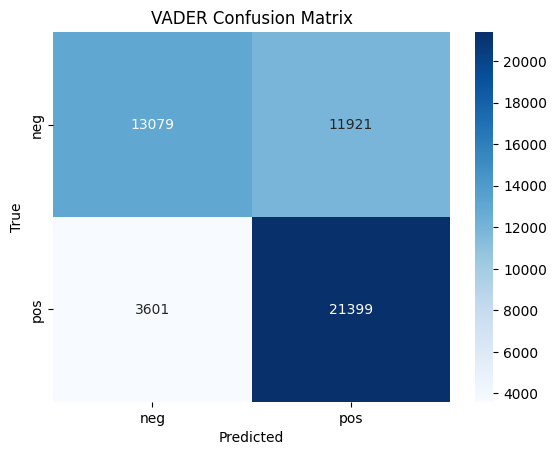

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns, matplotlib.pyplot as plt

y_true = df_vader['sentiment']
y_pred = df_vader['predicted_sentiment_vader']

print("Accuracy:", accuracy_score(y_true, y_pred))
print("\nClassification report:\n", classification_report(y_true, y_pred))

cm = confusion_matrix(y_true, y_pred, labels=['negative','positive'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['neg','pos'], yticklabels=['neg','pos'])
plt.title('VADER Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


In [ ]:
# 오류 샘플 확인(원인 파악하기 위함)
fp = (
    df_vader[
        (df_vader['sentiment'] == 'negative') &(df_vader['predicted_sentiment_vader'] == 'positive')]
    .sort_values('compound', ascending=False)
    .loc[:, ['review', 'clean_review', 'neg', 'neu', 'pos', 'compound']]
    .head(5)
)

fn = (
    df_vader[
        (df_vader['sentiment'] == 'positive') &(df_vader['predicted_sentiment_vader'] == 'negative')
    ]
    .sort_values('compound', ascending=True)
    .loc[:, ['review', 'clean_review', 'neg', 'neu', 'pos', 'compound']]
    .head(5)
)

display(fp); display(fn)


,review,clean_review,neg,neu,pos,compound
24590,"""It's like hard to like describe just how like...",like hard like describe like exciting like mak...,0.065,0.573,0.362,0.9994
410,I firmly believe that the best Oscar ceremony ...,firmly believe best oscar ceremony recent year...,0.111,0.503,0.385,0.9993
4220,"""Happy Days"" was produced and broadcast from t...",happy day produced broadcast mids early seems ...,0.080,0.629,0.290,0.9992
8648,The 1930' were a golden age of Los Angeles wit...,golden age los angeles film industry great pot...,0.093,0.531,0.376,0.9987
37793,by Dane Youssef<br /><br />I was kind of looki...,dane youssef kind looking forward one enjoy ed...,0.111,0.624,0.265,0.9984


,review,clean_review,neg,neu,pos,compound
45221,"""Nobi"" or ""Fires On the Plain"" is a film that ...",nobi fire plain film excellent many level not ...,0.377,0.482,0.140,-0.9996
4864,"**SPOILERS**Actually based on the novel ""The B...",spoilersactually based novel brick foxhole gay...,0.336,0.525,0.138,-0.9992
49772,CitizenX(1995) is the developing world's answe...,citizenx developing world answer silence lamb ...,0.271,0.602,0.127,-0.9990
30782,New York police detective Mark Dixon (Dana And...,new york police detective mark dixon dana andr...,0.351,0.561,0.088,-0.9989
24609,There's hell to pay when you cross Nami Matsus...,there hell pay cross nami matsushimameiko kaji...,0.308,0.552,0.140,-0.9989


### (3) 딥러닝-BERT

In [ ]:
# 1) 라이브러리
import pandas as pd
import torch
from transformers import pipeline

# 2) 데이터 (원본 50,000건도 동일)
df = pd.read_csv("/content/IMDB Dataset.csv")

# 3) GPU 설정
device = 0 if torch.cuda.is_available() else -1

# 4) 파이프라인
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    device=device
)

# 5) 텍스트
texts = df["review"].astype(str).tolist()

# 6) 배치 추론 (진행률 출력)
BATCH = 64  # GPU면 64~128, CPU면 16~32로
preds = []
for i in range(0, len(texts), BATCH):
    batch = texts[i:i+BATCH]
    out = sentiment_pipeline(
        batch,
        batch_size=BATCH,       # ★ pipeline 호출 시 배치 지정
        truncation=True,
        padding=True,
        max_length=256          # 속도/메모리와 정확도 타협점
    )
    preds.extend(out)
    if (i // BATCH) % 50 == 0:  # 가끔 진행상황 로그
        print(f"processed: {i + len(batch)} / {len(texts)}")

# 7) 결과 반영 및 평가
df["predicted_sentiment_bert"] = [p["label"].lower() for p in preds]
df["true_sentiment"] = df["sentiment"].map({"negative": 0, "positive": 1})
df["predicted_label_num"] = df["predicted_sentiment_bert"].map({"negative": 0, "positive": 1})

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print("정확도:", accuracy_score(df["true_sentiment"], df["predicted_label_num"]))
print("\n분류 보고서:\n", classification_report(df["true_sentiment"], df["predicted_label_num"]))
print("\n혼동 행렬:\n", confusion_matrix(df["true_sentiment"], df["predicted_label_num"]))


In [ ]:
df_errors = df[df["true_sentiment"] != df["predicted_label_num"]]
df_errors.sample(10)[["review", "sentiment", "predicted_sentiment_bert"]]


,review,sentiment,predicted_sentiment_bert
32550,If you go to this movie expecting something it...,positive,negative
19253,First off I am in my mid 40's. Been watchin ho...,negative,positive
28136,THE LAST WAVE is never going to win over the m...,positive,negative
31668,I am quite the Mitchell Leisen fan so it was a...,positive,negative
12683,I grew up watching this series. I was about se...,positive,negative
35968,As many have detailed here with a level of ser...,negative,positive
40756,Had this been the original 1914 version of TES...,positive,negative
22473,If The Lion King is a serious story about a yo...,positive,negative
9860,"This is a very interesting acquaintance! ""Two-...",negative,positive
20843,Theo Robertson has commented that WAW didn't a...,positive,negative


---

## 3. 모델 선정 및 해석

### **최종 모델: BERT**
                      
**선정 이유:**
1. 양방향 인코딩 구조 필요       
- 전처리 과정에서 데이터 살펴보았을 때, 긍정 리뷰에서 ‘not’이 높은 빈도로 등장함. -> ‘not bad at all’와 같은 문장은 단어 수준으로는 부정이지만, 실제 의미는 긍정
2. 정확도 및 F1-score      
- 다른 규칙기반 모델에 비해 BERT의 정확도(Accuracy: 약 0.87) 와 F1-score(약 0.87) 가 가장 높음


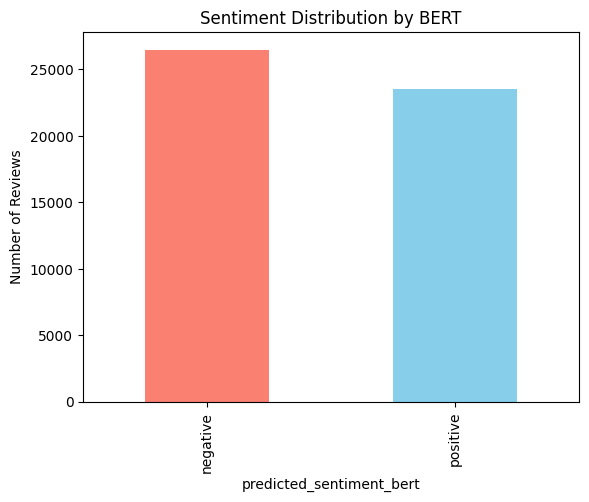

In [ ]:
import matplotlib.pyplot as plt

sentiment_counts = df['predicted_sentiment_bert'].value_counts()
sentiment_counts.plot(kind='bar', color=['salmon','skyblue'])
plt.title("Sentiment Distribution by BERT")
plt.ylabel("Number of Reviews")
plt.show()


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import re
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 텍스트 정제
def clean_text(text):
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'[^A-Za-z\s]', ' ', text)
    return text.lower()

df['clean_review'] = df['review'].astype(str).apply(clean_text)

# 긍정, 부정 나누기
pos_reviews = df[df['predicted_sentiment_bert'] == 'positive']['clean_review']
neg_reviews = df[df['predicted_sentiment_bert'] == 'negative']['clean_review']

# 1) bigram(2단어 표현) 추출기 정의
vectorizer = CountVectorizer(ngram_range=(2,2), stop_words='english', max_features=100)
X_pos = vectorizer.fit_transform(pos_reviews)
pos_phrases = pd.DataFrame({'phrase': vectorizer.get_feature_names_out(),
                            'freq': X_pos.sum(axis=0).A1}).sort_values('freq', ascending=False)

X_neg = vectorizer.fit_transform(neg_reviews)
neg_phrases = pd.DataFrame({'phrase': vectorizer.get_feature_names_out(),
                            'freq': X_neg.sum(axis=0).A1}).sort_values('freq', ascending=False)

# 2) 워드클라우드로 표현
wc_pos = WordCloud(width=800, height=400, background_color="white").generate_from_frequencies(
    dict(zip(pos_phrases['phrase'], pos_phrases['freq'])))

wc_neg = WordCloud(width=800, height=400, background_color="black").generate_from_frequencies(
    dict(zip(neg_phrases['phrase'], neg_phrases['freq'])))

# 3) 시각화
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(wc_pos)
plt.axis("off")
plt.title("Positive Bigrams", fontsize=14)

plt.subplot(1,2,2)
plt.imshow(wc_neg)
plt.axis("off")
plt.title("Negative Bigrams", fontsize=14)
plt.show()


In [ ]:
import re, pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from nltk.corpus import stopwords
import nltk
from wordcloud import WordCloud
import matplotlib.pyplot as plt

nltk.download('stopwords')

# 1) (이미 했다면 생략 가능) 가벼운 정제
def clean_text(t):
    t = re.sub(r'<.*?>', ' ', str(t))
    t = re.sub(r"[^a-zA-Z\s]", " ", t).lower()
    return re.sub(r"\s+", " ", t).strip()

df["clean_review"] = df["clean_review"].fillna("").apply(clean_text)

# 2) 불용어 (set -> list 로 전달!)
custom_stop = set(stopwords.words("english"))
custom_stop.update([
    'movie','film','one',
    'really','time','good','bad','even','much','also','well','get','make','made',
    'see','watch','watching','something','would','could','like','though',
    # 조동사/대명사/축약형
    "don","dont","didn","didnt","doesn","doesnt","isn","isnt","wasn","wasnt",
    "werent","havent","hasnt","cant","wont","ive","youre","im","weve",
    "seen","know","think","say","said","look","looks","looked"
])
stop_list = list(custom_stop)  # ★★★ 에러 해결 포인트

# 3) 긍/부정 텍스트
pos = df.loc[df["predicted_sentiment_bert"]=="positive","clean_review"]
neg = df.loc[df["predicted_sentiment_bert"]=="negative","clean_review"]

# 4) bigram 벡터라이저 (희소/일반 표현 제거용 파라미터 포함)
vect = CountVectorizer(
    ngram_range=(2,2),
    stop_words=stop_list,    # ★ list 로 전달
    min_df=5,                # 5문서 미만 표현 제거
    max_df=0.6,              # 너무 흔한 표현 제거
    token_pattern=r"(?u)\b[a-zA-Z]{2,}\b"
)

# Positive
X_pos = vect.fit_transform(pos)
pos_phr = pd.DataFrame({
    "phrase": vect.get_feature_names_out(),
    "freq": X_pos.sum(axis=0).A1
}).sort_values("freq", ascending=False)

# Negative (벡터라이저 새로!)
vect_neg = CountVectorizer(
    ngram_range=(2,2),
    stop_words=stop_list,
    min_df=5, max_df=0.6,
    token_pattern=r"(?u)\b[a-zA-Z]{2,}\b"
)
X_neg = vect_neg.fit_transform(neg)
neg_phr = pd.DataFrame({
    "phrase": vect_neg.get_feature_names_out(),
    "freq": X_neg.sum(axis=0).A1
}).sort_values("freq", ascending=False)

# 5) 워드클라우드
wc_pos = WordCloud(width=800, height=400, background_color="white")\
         .generate_from_frequencies(dict(zip(pos_phr.phrase, pos_phr.freq)))
wc_neg = WordCloud(width=800, height=400, background_color="black")\
         .generate_from_frequencies(dict(zip(neg_phr.phrase, neg_phr.freq)))

plt.figure(figsize=(12,6))
plt.subplot(1,2,1); plt.imshow(wc_pos); plt.axis("off"); plt.title("Positive Bigrams (Filtered)")
plt.subplot(1,2,2); plt.imshow(wc_neg); plt.axis("off"); plt.title("Negative Bigrams (Filtered)")
plt.show()

# (선택) 상위 표현 표로 확인
display(pos_phr.head(15))
display(neg_phr.head(15))


In [ ]:
df['sentiment_score'] = [p['score'] for p in preds]
df[['predicted_sentiment_bert','sentiment_score']].groupby('predicted_sentiment_bert').mean()


### **모델 결과 분석**          
- 긍증 키워드:              
love story, real life, special effects, new york, years ago, highly recommend, black white, sci fi  
              
  - 영화 스토리의 감동성과 현실 공감에 집중(love story, real life)
  - 배경 및 연출(new york, sci fi)
                    
- 부정 키워드:      
low budget, special effects, waste money, worst ever, main character, high school, real life, new york
     
  - 제작 퀄리티와 스토리 완성도 부족
  - 역시나 연출과 영화 내용에 집중
  - main character, high school 관련 표현이 반복됨→ 인물 구성이나 전개 방식에 대한 실망감 (캐릭터 몰입 부족)




---

## 4. 인사이트

### **누구에게:**
영화 마케팅 팀 및 홍보 담당자


### **어떤 가치를:**       

1. '감정 온도' 참여형 마케팅
  - 관객이 영화를 보고 느낀 감정을 ‘감정 온도(Emotion Temperature)’로 시각화하는 참여형 캠페인을 기획

                        

2. 심리적 예고편 마케팅

  - 감정분석에서 도출된 부정 표현(예: "지루할 줄 알았지만", "별 기대 없었지만")을 예고편 도입부에 활용

  - 후반부에서 긍정 감정("결국 울었다", "인생 영화였다")으로 반전되는 구조로 제작





### **어떻게:**
1. '감정 온도’ 참여형 마케팅
- 긍정 리뷰에서 자주 등장한 감정('감동', '공감', '현실적인 이야기')을 중심으로 감정 키워드별 온도를 실시간 차트로 공개

- 관객이 "감동받았다" 등 감정 키워드에 공감 버튼을 누를수록 온도가 상승하고, 입소문이 퍼질수록 감정 곡선이 변화하는 집단 감정 트래킹형 홍보 방식

2. 심리적 예고편 마케팅
- 과거 유사 장르 영화의 감정 패턴 데이터를 기반으로 관객이 예상한 감정과 실제 느낀 감정의 차이를 시각적으로 표현


### **어떤 가격으로**:
- 기존 광고 제작 예산 내에서 감정 분석 데이터 추가 활용    
(저비용·고효율 마케팅 실현 가능 예상)

### **얻는 방법:**

- 리뷰 데이터 수집 및 BERT 감정 분석 자동화 시스템 구축

- 영화 개봉 후 관객 리뷰 실시간 수집 -> 감정 변화 차트 자동 업데이트